<a href="https://colab.research.google.com/github/Megeeee/Machine-Learning/blob/main/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')


Using device: cuda
GPU Name: NVIDIA H100 80GB HBM3


In [24]:
transform = transforms.Compose([
    transforms.ToTensor(),
    # This shifts the pixels from [0, 1] to [-1, 1]
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [25]:
class Discriminator (nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            #1x28x28
            nn.Conv2d(1,32,kernel_size=3,stride=2,padding=1), #32x14x14
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Conv2d(32,64,kernel_size=3,stride=2,padding=1), #64x7x7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,kernel_size=3,stride=2,padding=1), #128x4x4
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128*4*4,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

In [26]:
class Generator(nn.Module):
  def __init__(self, latent_dim):
    super(Generator, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(latent_dim,128*7*7),
        nn.LeakyReLU(0.2),
        nn.Unflatten(1,(128,7,7)),#128x7x7
        nn.ConvTranspose2d(128,64,kernel_size=4,stride=2,padding=1),#64x14x14
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2),
        nn.ConvTranspose2d(64,1,kernel_size=4,stride=2,padding=1),#1x28x28

        nn.Tanh()
    )
  def forward(self,x):
    return self.model(x)

In [27]:
generator = Generator(100).to(device)
discriminator = Discriminator().to(device)

GeneratorOptim = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
DiscriminatorOptim = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

genLoss = nn.BCELoss()



Epoch [1/10] | Batch [300/938] | Discriminator Loss: 0.3274 | Generator Loss: 2.4044
Epoch [1/10] | Batch [600/938] | Discriminator Loss: 0.5035 | Generator Loss: 1.1027
Epoch [1/10] | Batch [900/938] | Discriminator Loss: 0.4524 | Generator Loss: 2.1113
Epoch [2/10] | Batch [300/938] | Discriminator Loss: 0.4002 | Generator Loss: 2.6215
Epoch [2/10] | Batch [600/938] | Discriminator Loss: 0.3585 | Generator Loss: 1.7696
Epoch [2/10] | Batch [900/938] | Discriminator Loss: 0.3897 | Generator Loss: 1.9971
Epoch [3/10] | Batch [300/938] | Discriminator Loss: 0.4433 | Generator Loss: 2.0996
Epoch [3/10] | Batch [600/938] | Discriminator Loss: 0.4615 | Generator Loss: 1.2472
Epoch [3/10] | Batch [900/938] | Discriminator Loss: 0.4152 | Generator Loss: 1.9160
Epoch [4/10] | Batch [300/938] | Discriminator Loss: 0.3970 | Generator Loss: 1.3215
Epoch [4/10] | Batch [600/938] | Discriminator Loss: 0.3848 | Generator Loss: 2.0572
Epoch [4/10] | Batch [900/938] | Discriminator Loss: 0.4147 | Gen

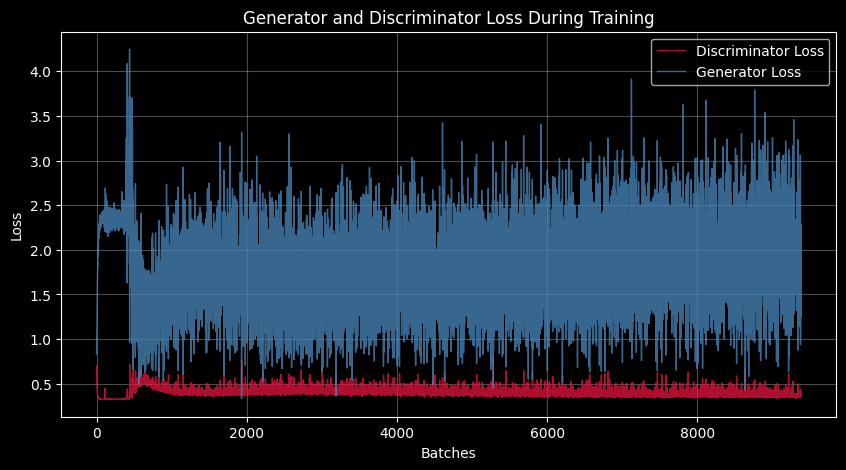

In [28]:
epoch = 10

d_losses = []
g_losses = []

for e in range(epoch):
  for idx, images in enumerate(dataloader):
    realimages = images[0].to(device)

    b_size = realimages.size(0)

    realpredictions = discriminator(realimages)
    discriminatorLoss1 = genLoss(realpredictions, torch.ones(b_size,1).to(device)*0.9)

    noise = torch.randn(b_size,100).to(device)
    fakeImages = generator(noise)
    fakePredictions = discriminator(fakeImages.detach())
    discriminatorLoss2 = genLoss(fakePredictions, torch.zeros(b_size,1).to(device)+0.1)


    discriminatorLoss = (discriminatorLoss1 + discriminatorLoss2)/2

    DiscriminatorOptim.zero_grad()
    discriminatorLoss.backward()
    DiscriminatorOptim.step()

    noise = torch.randn(b_size,100).to(device)
    fakeImages = generator(noise)
    generatorLoss = genLoss(discriminator(fakeImages), torch.ones(b_size,1).to(device))
    GeneratorOptim.zero_grad()
    generatorLoss.backward()
    GeneratorOptim.step()

    d_losses.append(discriminatorLoss.item())
    g_losses.append(generatorLoss.item())

    if (idx + 1) % 300 == 0:
        print(f"Epoch [{e + 1}/{epoch}] | Batch [{idx + 1}/{len(dataloader)}] "
              f"| Discriminator Loss: {discriminatorLoss.item():.4f} "
              f"| Generator Loss: {generatorLoss.item():.4f}")

print("Training Finished! Generating plot...")
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label="Discriminator Loss", color="crimson", alpha=0.8, linewidth=1)
plt.plot(g_losses, label="Generator Loss", color="steelblue", alpha=0.8, linewidth=1)
plt.title("Generator and Discriminator Loss During Training")
plt.xlabel("Batches")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

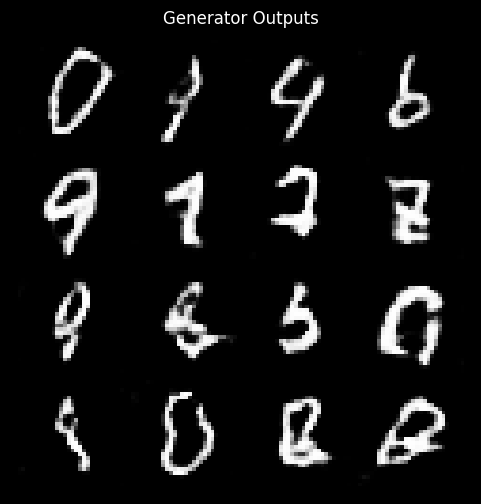

In [29]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import torch

def show_generated_images(generator, device, num_images=16):
    # 1. Create random noise (latent vectors)
    noise = torch.randn(num_images, 100).to(device)

    # 2. Turn off gradient tracking to save memory
    generator.eval()
    with torch.no_grad():
        # Generate the images and immediately move them back to the CPU
        fake_images = generator(noise).cpu()
    generator.train() # Put the generator back into training mode

    # 3. Denormalize the images from [-1, 1] back to [0, 1]
    fake_images = (fake_images + 1.0) / 2.0

    # 4. Create a clean grid of images
    # nrow=4 means 4 images per row (so a 4x4 grid for 16 images)
    grid = vutils.make_grid(fake_images, nrow=4, padding=2, normalize=False)

    # 5. Plot the grid
    plt.figure(figsize=(6, 6))
    plt.axis("off")
    plt.title("Generator Outputs")

    # Rearrange dimensions from (C, H, W) to (H, W, C) for Matplotlib
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.show()

# Call the function to see the images!
show_generated_images(generator, device)